# imports 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

Convert the data to a data frame 

In [2]:
df = pd.read_csv("customer_churn_practice.csv")


# 1. Display the first five rows and dataset shape

In [3]:
df.head()

,customer_id,age,plan_type,months_active,monthly_fee,avg_weekly_usage_hours,support_tickets_90d,late_payments_12m,auto_pay,satisfaction_score,region,churned
0,CUST-0001,38,Basic,6,27.90,3.6,2,0,Yes,9.0,West,0
1,CUST-0002,32,Basic,14,25.89,7.8,3,1,Yes,4.0,South,1
2,CUST-0003,53,Basic,54,21.06,9.9,1,0,No,7.0,Midwest,0
3,CUST-0004,35,Standard,1,47.46,4.3,0,0,No,NaN,South,1
4,CUST-0005,47,Basic,33,29.96,7.7,3,0,Yes,6.0,West,0


# 2. Create X containing the input features
Remove `customer_id` and `churned` from X

In [4]:
X = df.drop(columns=["churned", "customer_id"])

I originally wrote X = df.drop("churned", "customer_id"). Pandas requires multiple column names to be placed inside a list. I also needed to use columns= to tell pandas that I wanted to remove columns rather than rows. The correct format is df.drop(columns=["churned", "customer_id"]).


# 3. Create y containing the target column

In [5]:
y = df["churned"]
print(y.head())
print(y.shape)


0    0
1    1
2    0
3    1
4    0
Name: churned, dtype: int64
(800,)


# 4. Display the shapes and columns of X and y

In [6]:
print(X.shape)
print(y.shape)

(800, 10)
(800,)


# 5. Split the data into training and testing sets
Use 20% for testing, `random_state=42`, and stratify the target

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y) # add stratify=y to ensure the class distribution is maintained in both train and test sets

# 6. Display the shapes of all four training and testing variables

In [8]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(640, 10) (160, 10) (640,) (160,)


# 7. Compare the churn percentages in `y_train` and `y_test`

In [9]:
percentTrain = y_train.value_counts(normalize=True) * 100 # normalize=True gives proportions, then multiplying by 100 turns them into percentages.
percentTest = y_test.value_counts(normalize=True) * 100
print("Percent train y:", percentTrain)
print("Percent test y:", percentTest)


Percent train y: churned
0    68.4375
1    31.5625
Name: proportion, dtype: float64
Percent test y: churned
0    68.125
1    31.875
Name: proportion, dtype: float64


Stratification worked because the training and testing sets have almost the same class percentages. In the churned target, 0 represents a customer who did not churn, while 1 represents a customer who churned.

# 8. Create a list of numerical feature names

In [10]:
numerical_features = [
    "age", "months_active", "monthly_fee", "avg_weekly_usage_hours", "support_tickets_90d", "late_payments_12m", "satisfaction_score"
]

X[numerical_features].head()


,age,months_active,monthly_fee,avg_weekly_usage_hours,support_tickets_90d,late_payments_12m,satisfaction_score
0,38,6,27.90,3.6,2,0,9.0
1,32,14,25.89,7.8,3,1,4.0
2,53,54,21.06,9.9,1,0,7.0
3,35,1,47.46,4.3,0,0,NaN
4,47,33,29.96,7.7,3,0,6.0


# 9. Create a list of categorical feature names

In [11]:
categorical_features = ["plan_type", "auto_pay", "region"]

X[categorical_features].head()

,plan_type,auto_pay,region
0,Basic,Yes,West
1,Basic,Yes,South
2,Basic,No,Midwest
3,Standard,No,South
4,Basic,Yes,West


# 10. Create the numerical preprocessing steps
Replace missing values with the median
Scale the numerical features

In [12]:
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

What this means:
- Pipeline(...) runs steps in order.
- "imputer" fills missing numeric values.
- SimpleImputer(strategy="median") replaces missing values with the median of that column.
- "scaler" scales numeric values.
- StandardScaler() puts numeric columns on a similar scale, which helps Logistic Regression.

# 11. Create the categorical preprocessing steps
Replace missing values with the most frequent value
One-hot encode the categorical features

In [13]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

What this means:
- Missing category values get replaced with the most common category.
- OneHotEncoder turns text categories into numeric 0/1 columns.
- handle_unknown="ignore" prevents errors if the test set has a category that was not seen during training.

# 12. Combine the numerical and categorical preprocessing

In [14]:
preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

What this means:
- ColumnTransformer applies different preprocessing to different columns.
- "num" applies numerical_transformer to your numerical_features.
- "cat" applies categorical_transformer to your categorical_features.
- This lets one pipeline handle both numeric and categorical data correctly.

# 13. Create and train a baseline DummyClassifier

In [15]:
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(strategy="most_frequent"))
])

baseline_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


What this means:
- This creates a baseline model.
- It first preprocesses the data.
- Then `DummyClassifier(strategy="most_frequent")` always predicts the most common class.
- In your dataset, that likely means it mostly predicts "stayed."
- `.fit(X_train, y_train)` trains the pipeline on the training data.

# 14. Make baseline predictions and evaluate the baseline

In [16]:
baseline_predictions = baseline_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, baseline_predictions))
print("Precision:", precision_score(y_test, baseline_predictions, zero_division=0))
print("Recall:", recall_score(y_test, baseline_predictions, zero_division=0))
print("F1:", f1_score(y_test, baseline_predictions, zero_division=0))

Accuracy: 0.68125
Precision: 0.0
Recall: 0.0
F1: 0.0


What this means:
- `.predict(X_test)` makes predictions on data the model did not train on.
- `y_test` contains the real answers.
- `baseline_predictions` contains the model's guesses.
- The metric functions compare real answers against predicted answers.

# 15. Create a pipeline containing preprocessing and Logistic Regression

In [ ]:
log_reg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000), class)
])

What this means:
- This creates your real Logistic Regression model pipeline.
- It uses the same preprocessing from #12.
- Then it trains Logistic Regression on the cleaned/encoded/scaled data.
- max_iter=1000 gives the model more time to converge.

# 16. Train the Logistic Regression pipeline

In [18]:
log_reg_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


What this means:
- `.fit(X_train, y_train)` trains the full pipeline.
- The preprocessing steps learn from the training data only.
- Logistic Regression then learns patterns that separate stayed customers from churned customers.

# 17. Make predictions using the testing data

In [19]:
log_reg_predictions = log_reg_model.predict(X_test)

What this means:
- `.predict(X_test)` uses the trained pipeline on the testing data.
- `log_reg_predictions` contains the model's predicted class for each test customer.
- These predictions should be compared against `y_test`, which contains the real answers.

# 18. Calculate accuracy, precision, recall, and F1 score

In [20]:
print("Accuracy:", accuracy_score(y_test, log_reg_predictions))
print("Precision:", precision_score(y_test, log_reg_predictions, zero_division=0))
print("Recall:", recall_score(y_test, log_reg_predictions, zero_division=0))
print("F1:", f1_score(y_test, log_reg_predictions, zero_division=0))

Accuracy: 0.78125
Precision: 0.7105263157894737
Recall: 0.5294117647058824
F1: 0.6067415730337079


What this means:
- Accuracy measures the overall percent of correct predictions.
- Precision asks: when the model predicted churn, how often was it right?
- Recall asks: out of the customers who actually churned, how many did the model catch?
- F1 combines precision and recall into one score.

# 19. Display the classification report

In [21]:
print(classification_report(y_test, log_reg_predictions))

              precision    recall  f1-score   support

           0       0.80      0.90      0.85       109
           1       0.71      0.53      0.61        51

    accuracy                           0.78       160
   macro avg       0.76      0.71      0.73       160
weighted avg       0.77      0.78      0.77       160



What this means:
- The classification report shows precision, recall, and F1 for each class.
- Class `0` means the customer stayed.
- Class `1` means the customer churned.
- For churn prediction, pay close attention to the class `1` recall and F1 score.

# 20. Create and display the confusion matrix

In [22]:
conf_matrix = confusion_matrix(y_test, log_reg_predictions)
conf_matrix

array([[98, 11],
       [24, 27]])

What this means:
- The confusion matrix compares real classes against predicted classes.
- It helps you see the actual mistake types, not just one summary score.
- The most important mistakes for churn are often missed churners: real churned customers predicted as stayed.

# 21. Create a heatmap of the confusion matrix

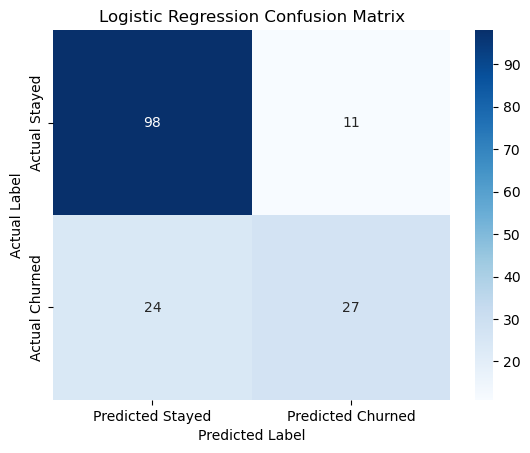

In [23]:
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Stayed", "Predicted Churned"],
    yticklabels=["Actual Stayed", "Actual Churned"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

What this means:
- The heatmap displays the confusion matrix visually.
- Darker cells represent larger counts.
- This makes it easier to see where the model is correct and where it makes mistakes.

## Final reflection questions

1. Did Logistic Regression perform better than the DummyClassifier? How do you know?

   Answer: The Logistic regression did about 10% better than the Dummy classifier 


2. Which metric is most important for this churn problem: accuracy, precision, recall, or F1 score? Why?

   Answer: The recall is the most important becuse it shows how bad the model did at predicting if a customer would churn and it missed about 47% of those causing the busness to lose customers.  


3. What does recall for class `1` mean in this project?

   Answer: The recall represents what the model got correct out of all real churn values. 


4. What does precision for class `1` mean in this project?

   Answer: Out of all customers the model predicted would churn, how many actually churned.


5. Based on the classification report, is the model better at predicting customers who stayed or customers who churned?

   Answer: its better at predicting customers who stayed. 


6. What does the confusion matrix show about the model's mistakes?

   Answer: It predicts stayed more often, so it misses some customers who actually churned.  


7. Would this Logistic Regression model be good enough for a business to use right away? Why or why not?

   Answer: No, because it missed about 47% of customers who actually churned. A business would probably want better recall before using this model.

8. What is one thing you could try next to improve the model?

   Answer: I would try using class weights to make the model pay more attention to churned customers.